In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

sns.set(style="whitegrid")

connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password=password,
        database="expense_tracker"
)

In [5]:
query = "SELECT * FROM expenses"
df = pd.read_sql(query, conn)

print(df.head())

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

   id        date       category payment_mode  \
0   1  2025-04-15           Food   Debit Card   
1   2  2025-08-11     Healthcare         Cash   
2   3  2025-08-11         Travel   Debit Card   
3   4  2025-07-01  Subscriptions  Credit Card   
4   5  2025-08-09       Shopping   Debit Card   

                               description  amount_paid  cashback  
0  Visit study child drive bar democratic.      4595.33      0.00  
1    Respond color still wide kind likely.      2822.27      0.00  
2               Night west recognize nice.      4024.26    354.81  
3                Describe sell than trade.      4683.27      0.00  
4                  Successful begin think.      2677.17    213.33  
Shape of dataset: (300, 7)

Column names:
Index(['id', 'date', 'category', 'payment_mode', 'description', 'amount_paid',
       'cashback'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Col

C:\Users\paris\AppData\Local\Temp\ipykernel_2708\68460198.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [6]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
id              0
date            0
category        0
payment_mode    0
description     0
amount_paid     0
cashback        0
dtype: int64


In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               id  amount_paid    cashback
count  300.000000   300.000000  300.000000
mean   150.500000  2659.457267   41.577867
std     86.746758  1462.389560   86.333694
min      1.000000   100.580000    0.000000
25%     75.750000  1392.902500    0.000000
50%    150.500000  2569.020000    0.000000
75%    225.250000  4030.490000   43.960000
max    300.000000  4996.360000  467.550000


In [20]:
# Step 6: Convert date column
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_name'] = df['date'].dt.day_name()

df.head()

,id,date,category,payment_mode,description,amount_paid,cashback,month,year,day_name
0,1,2025-04-15,Food,Debit Card,Visit study child drive bar democratic.,4595.33,0.00,4,2025,Tuesday
1,2,2025-08-11,Healthcare,Cash,Respond color still wide kind likely.,2822.27,0.00,8,2025,Monday
2,3,2025-08-11,Travel,Debit Card,Night west recognize nice.,4024.26,354.81,8,2025,Monday
3,4,2025-07-01,Subscriptions,Credit Card,Describe sell than trade.,4683.27,0.00,7,2025,Tuesday
4,5,2025-08-09,Shopping,Debit Card,Successful begin think.,2677.17,213.33,8,2025,Saturday


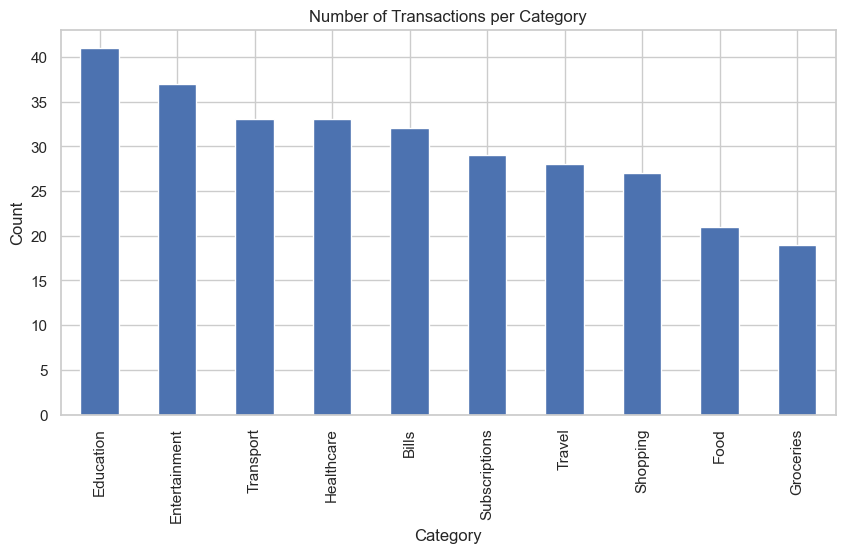

In [19]:
# Step 7: Category distribution
plt.figure(figsize=(10,5))

df['category'].value_counts().plot(kind='bar')

plt.title("Number of Transactions per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

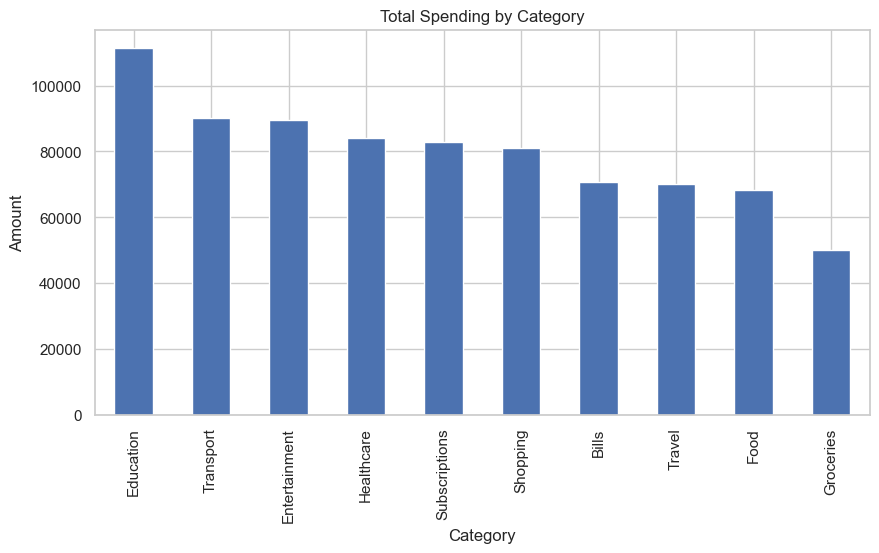

In [18]:
# Step 8: Total spending by category
category_spending = df.groupby('category')['amount_paid'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

category_spending.plot(kind='bar')

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.show()

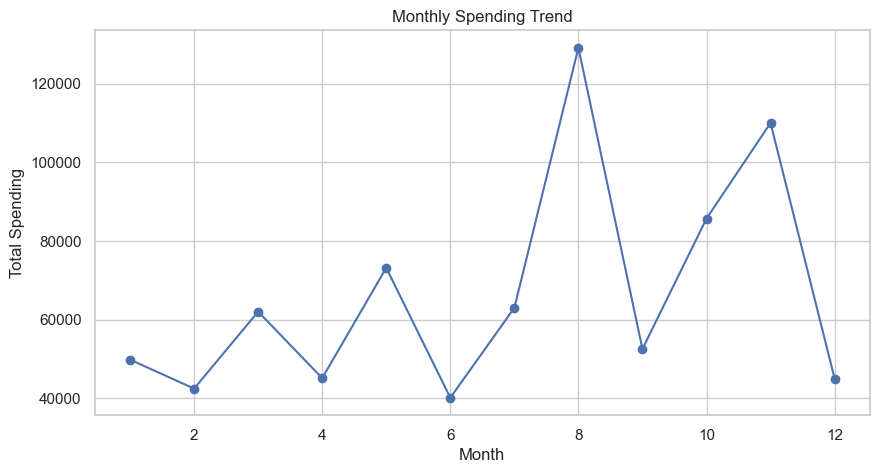

In [16]:
# Step 9: Monthly spending trend
monthly_spending = df.groupby('month')['amount_paid'].sum()

plt.figure(figsize=(10,5))
monthly_spending.plot(marker='o')

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.show()

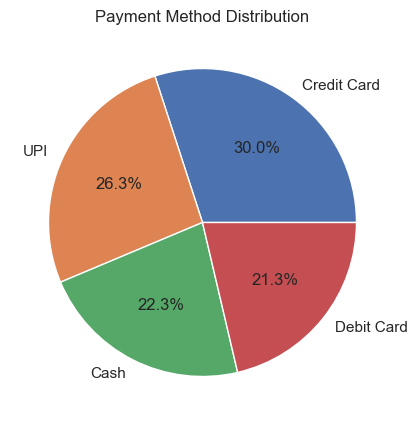

In [17]:
# Step 10: Payment method usage
plt.figure(figsize=(8,5))

df['payment_mode'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

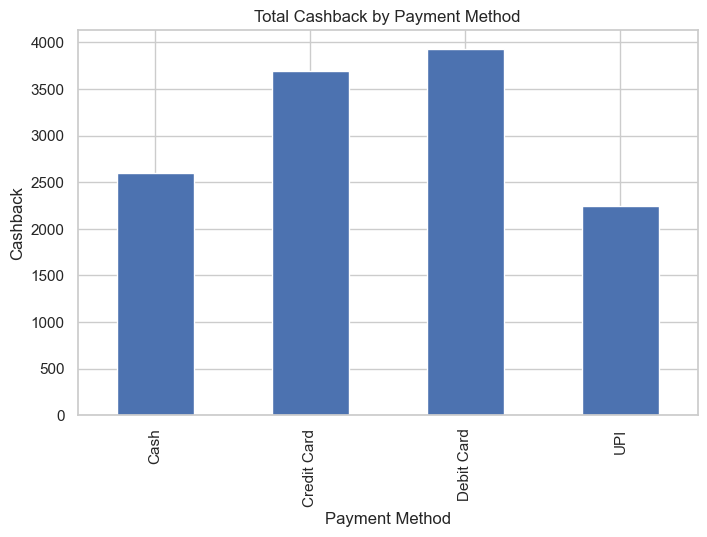

In [22]:
# Step 11: Cashback analysis

cashback_by_method = df.groupby('payment_mode')['cashback'].sum()

plt.figure(figsize=(8,5))

cashback_by_method.plot(kind='bar')

plt.title("Total Cashback by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Cashback")

plt.show()

In [26]:
# Step 12: Detect high-value transactions

high_value = df[df['amount_paid'] > df['amount_paid'].quantile(0.9)]

print("Top 10% High Value Transactions:")
print(high_value[['category','amount_paid','payment_mode']].head())

Top 10% High Value Transactions:
         category  amount_paid payment_mode
3   Subscriptions      4683.27  Credit Card
10           Food      4730.98   Debit Card
38         Travel      4829.64          UPI
45  Entertainment      4850.44          UPI
57      Transport      4956.10   Debit Card


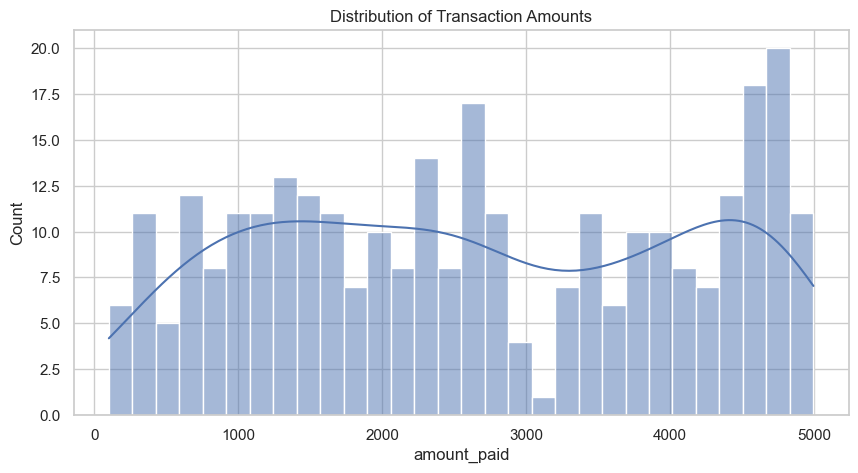

In [28]:
# Step 13: Distribution of transaction amounts

plt.figure(figsize=(10,5))

sns.histplot(df['amount_paid'], bins=30, kde=True)

plt.title("Distribution of Transaction Amounts")

plt.show()


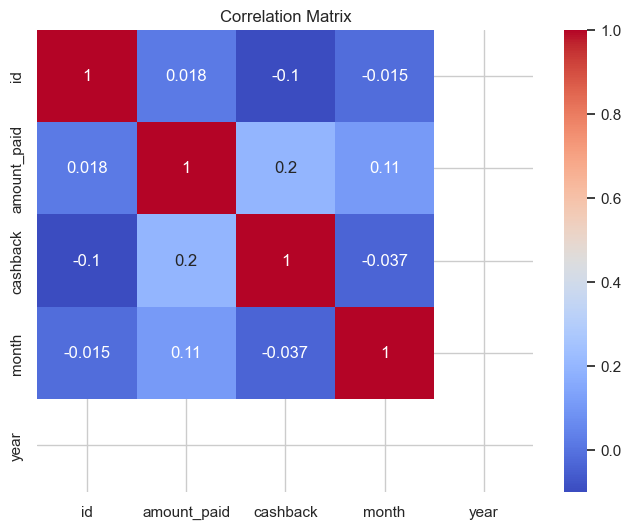

In [29]:
# Step 14: Correlation matrix

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

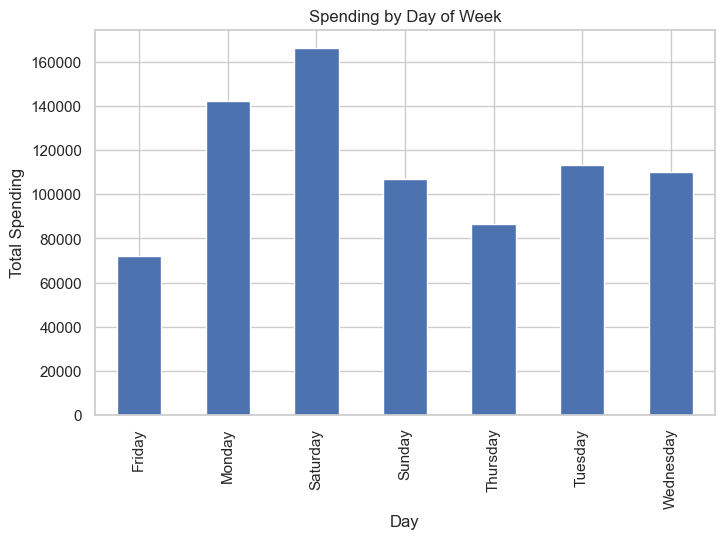

In [31]:
# Step 15: Spending by day of week

spending_by_day = df.groupby('day_name')['amount_paid'].sum()

plt.figure(figsize=(8,5))

spending_by_day.plot(kind='bar')

plt.title("Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Spending")

plt.show()